##### Copyright 2018 The TensorFlow Authors.


:The model architecture built in this tutorial is shown below. Features are extracted from the image, and passed to the cross-attention layers of the Transformer-decoder.

<table>
<tr>
  <th>The model architecture</th>
</tr>
<tr>
  <td>
   <img width=400 src="https://tensorflow.org/images/tutorials/transformer/ImageCaptioning.png"/>
  </td>
</tr>
</table>

The transformer decoder is mainly built from attention layers. It uses self-attention to process the sequence being generated, and it uses cross-attention to attend to the image.

By inspecting the attention weights of the cross attention layers you will see what parts of the image the model is looking at as it generates words.

![Prediction](https://tensorflow.org/images/imcap_prediction.png)

This notebook is an end-to-end example. When you run the notebook, it downloads a dataset, extracts and caches the image features, and trains a decoder model. It then uses the model to generate captions on new images.

## Setup

In [ ]:
# !apt install --allow-change-held-packages libcudnn8=8.6.0.163-1+cuda11.8

In [ ]:
# !pip uninstall -y tensorflow estimator keras

In [ ]:
# !pip install -U tensorflow_text tensorflow tensorflow_datasets

In [ ]:
# !pip install einops

In [ ]:
# !pip install unrar

This tutorial uses lots of imports, mostly for loading the dataset(s).

#@title
import concurrent.futures
import collections
import dataclasses
import hashlib
import itertools
import json
import math
import os
import pathlib
import random
import re
import string
import time
import urllib.request

import einops
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import requests
import tqdm

import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_text as text
import tensorflow_datasets as tfds

## [Optional] Data handling

This section downloads a captions dataset and prepares it for training. It tokenizes the input text, and caches the results of running all the images through a pretrained feature-extractor model. It's not critical to understand everything in this section.

 <section class="expandable tfo-display-only-on-site">
 <button type="button" class="button-red button expand-control">Toggle section</button>


In [ ]:
# @title
import concurrent.futures
import collections
import dataclasses
import hashlib
import itertools
import json
import math
import os
import pathlib
import random
import re
import string
import time
import urllib.request

import einops
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import requests
import tqdm

import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_text as text
import tensorflow_datasets as tfds
from tensorflow.keras.models import load_model, Model
import numpy as np
from tensorflow.keras.applications import EfficientNetB0

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unrar x -y "drive/MyDrive/mnb/images.rar" "output_folder/"

In [ ]:
# path = pathlib.Path('drive')
# captions = (path/"MyDrive/AAHR_dataset/labels.token.txt").read_text().splitlines()
# random.shuffle(captions)
# test_captions = [line.split('    ') for line in captions][26081:]
# with open("drive/MyDrive/AAHR_dataset/labels.testImages.txt", "w") as file:
#   for a,b in test_captions:
#     file.write(a+'\n')
# train_captions = [line.split('    ') for line in captions][:26080]
# with open("drive/MyDrive/AAHR_dataset/labels.trainImages.txt", "w") as file:
#   for a,b in train_captions:
#     file.write(a+'\n')

In [ ]:
batch_size = 32
IMAGE_SHAPE = (70, 800, 3)
height, width = 70, 800

### Choose a dataset

This tutorial is set up to give a choice of datasets. Either [Flickr8k](https://www.ijcai.org/Proceedings/15/Papers/593.pdf) or a small slice of the [Conceptual Captions](https://ai.google.com/research/ConceptualCaptions/) dataset. These two are downloaded and converted from scratch, but it wouldn't be hard to convert the tutorial to use the caption datasets available in [TensorFlow Datasets](https://www.tensorflow.org/datasets): [Coco Captions](https://www.tensorflow.org/datasets/catalog/coco_captions) and the full [Conceptual Captions](https://www.tensorflow.org/datasets/community_catalog/huggingface/conceptual_captions).


In [ ]:
def load_dataset():
    path = pathlib.Path("drive")
    captions = (path / "MyDrive/mnb/labels.token.txt").read_text().splitlines()
    captions = (line.split("    ") for line in captions)
    captions = ((fname, caption) for (fname, caption) in captions)
    cap_dict = collections.defaultdict(list)
    for fname, cap in captions:
        cap_dict[fname].append(cap)

    localPath = pathlib.Path("output_folder")
    train_files = (path / "MyDrive/mnb/labels.trainImages.txt").read_text().splitlines()
    train_captions = [
        (str(localPath / "images" / fname), cap_dict[fname]) for fname in train_files
    ]

    test_files = (path / "MyDrive/mnb/labels.testImages.txt").read_text().splitlines()
    test_captions = [
        (str(localPath / "images" / fname), cap_dict[fname]) for fname in test_files
    ]

    train_ds = tf.data.experimental.from_list(train_captions)
    test_ds = tf.data.experimental.from_list(test_captions)

    return train_ds, test_ds

#### Flickr8k

In [ ]:
train_raw, test_raw = load_dataset()

#### Conceptual Captions

#### Download the dataset

The Flickr8k is a good choice because it contains 5-captions per image, more data for a smaller download.

> Add blockquote



choose = 'flickr8k'

if choose == 'flickr8k':
  train_raw, test_raw = flickr8k()
else:
  train_raw, test_raw = conceptual_captions(num_train=10000, num_val=5000)

The loaders for both datasets above return `tf.data.Dataset`s containing `(image_path, captions)` pairs. The Flickr8k dataset contains 5 captions per image, while Conceptual Captions has 1:

In [ ]:
train_raw.element_spec

(TensorSpec(shape=(), dtype=tf.string, name=None),
 TensorSpec(shape=(1,), dtype=tf.string, name=None))

In [ ]:
for ex_path, ex_captions in train_raw.take(1):
    print(ex_path)
    print(ex_captions.numpy()[0].decode())

tf.Tensor(b'output_folder/images/line_19650.jpg', shape=(), dtype=string)
ﺑﺬﻟﻚ ﺍﻟﺒﺨﺎﺭ ﻏﻠﻆ ﺍﻟﺨﻠﻂ ﺍﻟﺬﻱ ﻓﻲ ﺃﺩﻣﻐﺘﻬﻢ ﻃﺒﻴﺦ ﺍﻟﻔﻮﺗﻨﺞ ﻭﺍﻟﺤﺎﺷﺎ ﺑﺨﻞ ﻛﻴﻤﺎ ﻳﻘﻄﻊ


In [ ]:
import cv2 as cv

image = cv.imread("output_folder/images/line_10000.jpg")
print(image.shape)

(70, 800, 3)


### Image feature extractor

You will use an image model (pretrained on imagenet) to extract the features from each image. The model was trained as an image classifier, but setting `include_top=False` returns the model without the final classification layer, so you can use the last layer of feature-maps:  


In [ ]:
# # convert mobilenet modle to DiT (Document Image Transformer):
# mobilenet = tf.keras.applications.MobileNetV3Small(
#     input_shape=IMAGE_SHAPE,
#     include_top=False,
#     include_preprocessing=True)
# mobilenet.trainable=True


# mobilenet = EfficientNetB0(
#     input_shape=IMAGE_SHAPE,
#     weights='imagenet',
#     include_top=False
# )

# mobilenet.trainable = True


mobilenet = load_model("drive/MyDrive/text_feature_extractor_v4.keras")
mobilenet.trainable = True

Here's a function to load an image and resize it for the model:

In [ ]:
import tensorflow as tf

TARGET_HEIGHT = 70
TARGET_WIDTH = 800


def get_border_mean(img):
    top = tf.reshape(img[0:1, :, :], [-1, 3])
    bottom = tf.reshape(img[-1:, :, :], [-1, 3])
    left = tf.reshape(img[:, 0:1, :], [-1, 3])
    right = tf.reshape(img[:, -1:, :], [-1, 3])
    edges = tf.concat([top, bottom, left, right], axis=0)
    return tf.reduce_mean(edges, axis=0)


def resize_or_pad(img):
    h = tf.shape(img)[0]
    w = tf.shape(img)[1]

    # If image is larger → resize keeping aspect ratio
    scale = tf.minimum(
        TARGET_HEIGHT / tf.cast(h, tf.float32), TARGET_WIDTH / tf.cast(w, tf.float32)
    )

    new_h = tf.cast(tf.cast(h, tf.float32) * scale, tf.int32)
    new_w = tf.cast(tf.cast(w, tf.float32) * scale, tf.int32)
    img = tf.image.resize(img, [new_h, new_w], method=tf.image.ResizeMethod.AREA)

    # Compute padding
    pad_height = TARGET_HEIGHT - new_h
    pad_width = TARGET_WIDTH - new_w
    pad_top = pad_height // 2
    pad_bottom = pad_height - pad_top
    pad_left = pad_width // 2
    pad_right = pad_width - pad_left

    # Border-based pad color
    pad_color = get_border_mean(img)

    # Make padded image with pad_color
    img = tf.image.pad_to_bounding_box(
        img, pad_top, pad_left, TARGET_HEIGHT, TARGET_WIDTH
    )

    # Fill padded areas with pad_color
    mask = tf.pad(
        tf.ones([new_h, new_w, 3], dtype=img.dtype),
        [[pad_top, pad_bottom], [pad_left, pad_right], [0, 0]],
    )
    img = img * mask + (1 - mask) * pad_color

    return tf.cast(img, tf.uint8)

In [ ]:
def load_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = resize_or_pad(img)
    img = tf.cast(img, tf.float32) / 255.0
    return img

The model returns a feature map for each image in the input batch:

In [ ]:
test_img_batch = load_image(ex_path)[tf.newaxis, :]


print(test_img_batch.shape)
print(mobilenet(test_img_batch).shape)

(1, 70, 800, 3)
(1, 3, 25, 1280)


### Setup the text tokenizer/vectorizer

You will transform the text captions into integer sequences using the [TextVectorization](https://www.tensorflow.org/api_docs/python/tf/keras/layers/TextVectorization) layer, with the following steps:

* Use [adapt](https://www.tensorflow.org/api_docs/python/tf/keras/layers/TextVectorization#adapt) to iterate over all captions, split the captions into words, and compute a vocabulary of the top words.
* Tokenize all captions by mapping each word to its index in the vocabulary. All output sequences will be padded to length 50.
* Create word-to-index and index-to-word mappings to display results.

In [ ]:
def standardize(s):
    s = tf.strings.regex_replace(s, f"[{re.escape(string.punctuation)}]", "")
    s = tf.strings.join(["[START]", s, "[END]"], separator=" ")
    return s

In [ ]:
# Use the top 5000 words for a vocabulary.
vocabulary_size = 500000
tokenizer = tf.keras.layers.TextVectorization(
    max_tokens=vocabulary_size, standardize=standardize, ragged=True
)
# Learn the vocabulary from the caption data.

In [ ]:
tokenizer.adapt(train_raw.map(lambda fp, txt: txt).unbatch().batch(1024))

In [ ]:
tokenizer.get_vocabulary()[:10]

['',
 '[UNK]',
 np.str_('[START]'),
 np.str_('[END]'),
 np.str_('ﻣﻦ'),
 np.str_('ﻓﻲ'),
 np.str_('ﺃﻥ'),
 np.str_('من'),
 np.str_('ﻗﺎﻝ'),
 np.str_('ﻛﺎﻥ')]

In [ ]:
t = tokenizer([["الشراب اليه الحلو البارد و ينبغى ان لا يكون شديد"]])
t

<tf.RaggedTensor [[2, 22314, 552, 7492, 8432, 327, 6283, 18, 44, 230, 2421, 3]]>

In [ ]:
# Create mappings for words to indices and indices to words.
word_to_index = tf.keras.layers.StringLookup(
    mask_token="", vocabulary=tokenizer.get_vocabulary()
)
index_to_word = tf.keras.layers.StringLookup(
    mask_token="", vocabulary=tokenizer.get_vocabulary(), invert=True
)

In [ ]:
w = index_to_word(t)
w.to_list()

[[b'[START]',
  b'\xd8\xa7\xd9\x84\xd8\xb4\xd8\xb1\xd8\xa7\xd8\xa8',
  b'\xd8\xa7\xd9\x84\xd9\x8a\xd9\x87',
  b'\xd8\xa7\xd9\x84\xd8\xad\xd9\x84\xd9\x88',
  b'\xd8\xa7\xd9\x84\xd8\xa8\xd8\xa7\xd8\xb1\xd8\xaf',
  b'\xd9\x88',
  b'\xd9\x8a\xd9\x86\xd8\xa8\xd8\xba\xd9\x89',
  b'\xd8\xa7\xd9\x86',
  b'\xd9\x84\xd8\xa7',
  b'\xd9\x8a\xd9\x83\xd9\x88\xd9\x86',
  b'\xd8\xb4\xd8\xaf\xd9\x8a\xd8\xaf',
  b'[END]']]

In [ ]:
tf.strings.reduce_join(w, separator=" ", axis=-1).numpy()[0].decode()

'[START] الشراب اليه الحلو البارد و ينبغى ان لا يكون شديد [END]'

### Prepare the datasets

The `train_raw` and `test_raw` datasets contain 1:many `(image, captions)` pairs.

This function will replicate the image so there are 1:1 images to captions:

In [ ]:
def match_shapes(images, captions):
    caption_shape = einops.parse_shape(captions, "b c")
    captions = einops.rearrange(captions, "b c -> (b c)")
    images = einops.repeat(images, "b ... -> (b c) ...", c=caption_shape["c"])
    return images, captions

In [ ]:
for ex_paths, ex_captions in train_raw.batch(batch_size).take(1):
    break

print("image paths:", ex_paths.shape)
print("captions:", ex_captions.shape)
print()

ex_paths, ex_captions = match_shapes(images=ex_paths, captions=ex_captions)

print("image_paths:", ex_paths.shape)
print("captions:", ex_captions.shape)

image paths: (32,)
captions: (32, 1)

image_paths: (32,)
captions: (32,)


To be compatible with keras training the dataset should contain `(inputs, labels)` pairs. For text generation the tokens are both an input and the labels, shifted by one step. This function will convert an `(images, texts)` pair to an `((images, input_tokens), label_tokens)` pair:

In [ ]:
def prepare_txt(imgs, txts):
    tokens = tokenizer(txts)

    input_tokens = tokens[..., :-1]
    label_tokens = tokens[..., 1:]
    return (imgs, input_tokens), label_tokens

This function adds operations to a dataset. The steps are:

1. Load the images (and ignore images that fail to load).
2. Replicate images to match the number of captions.
3. Shuffle and rebatch the `image, caption` pairs.
4. Tokenize the text, shift the tokens and add `label_tokens`.
5. Convert the text from a `RaggedTensor` representation to padded dense `Tensor` representation.

In [ ]:
def prepare_dataset(ds, tokenizer, batch_size=batch_size, shuffle_buffer=256):
    ds = ds.shuffle(shuffle_buffer)
    ds = ds.map(lambda path, caption: (load_image(path), caption))
    ds = ds.apply(tf.data.Dataset.ignore_errors)
    ds = ds.batch(batch_size)

    def to_tensor(inputs, labels):
        (images, in_tok), out_tok = inputs, labels
        return (images, in_tok.to_tensor()), out_tok.to_tensor()

    ds = ds.map(match_shapes, tf.data.AUTOTUNE)
    ds = ds.unbatch().shuffle(shuffle_buffer).batch(batch_size)
    ds = ds.map(
        prepare_txt, tf.data.AUTOTUNE
    )  # Tokenize and prepare input/label sequences
    ds = ds.map(to_tensor, tf.data.AUTOTUNE)

    return ds

You could install the feature extractor in your model and train on the datasets like this:

In [ ]:
train_ds = prepare_dataset(train_raw, tokenizer)
train_ds.element_spec

((TensorSpec(shape=(None, 70, 800, 3), dtype=tf.float32, name=None),
  TensorSpec(shape=(None, None), dtype=tf.int64, name=None)),
 TensorSpec(shape=(None, None), dtype=tf.int64, name=None))

In [ ]:
test_ds = prepare_dataset(test_raw, tokenizer)
test_ds.element_spec

((TensorSpec(shape=(None, 70, 800, 3), dtype=tf.float32, name=None),
  TensorSpec(shape=(None, None), dtype=tf.int64, name=None)),
 TensorSpec(shape=(None, None), dtype=tf.int64, name=None))

### [Optional] Cache the image features

Since the image feature extractor is not changing, and this tutorial is not using image augmentation, the image features can be cached. Same for the text tokenization. The time it takes to set up the cache is earned back on each epoch during training and validation. The code below defines two functions `save_dataset` and `load_dataset`:

In [ ]:
def save_dataset(ds, save_path, image_model, tokenizer, shards=10):
    # Load the images and make batches.
    ds = (
        ds.map(lambda path, caption: (load_image(path), caption))
        .apply(tf.data.Dataset.ignore_errors)
        .batch(batch_size)
    )

    # Run the feature extractor on each batch
    # Don't do this in a .map, because tf.data runs on the CPU.

    def gen():
        for images, captions in tqdm.tqdm(ds):
            feature_maps = image_model(images)

            feature_maps, captions = match_shapes(feature_maps, captions)
            yield feature_maps, captions

    # Wrap the generator in a new tf.data.Dataset.

    new_ds = tf.data.Dataset.from_generator(
        gen,
        output_signature=(
            tf.TensorSpec(shape=image_model.output_shape),
            tf.TensorSpec(shape=(None,), dtype=tf.string),
        ),
    )

    # Apply the tokenization
    new_ds = ds.map(prepare_txt, tf.data.AUTOTUNE).unbatch()

    # Save the dataset into shard files.
    def shard_func(i, item):
        return i % shards

    new_ds.enumerate().save(save_path, shard_func=shard_func)


def load_dataset(save_path, shuffle=256, cycle_length=2):
    def custom_reader_func(datasets):
        datasets = datasets.shuffle(shuffle)
        return datasets.interleave(lambda x: x, cycle_length=cycle_length)

    ds = tf.data.Dataset.load(save_path, reader_func=custom_reader_func)

    def drop_index(i, x):
        return x

    ds = (
        ds.map(drop_index, tf.data.AUTOTUNE)
        .shuffle(shuffle)
        .padded_batch(batch_size)
        .prefetch(tf.data.AUTOTUNE)
    )
    return ds

In [ ]:
# save_dataset(train_raw, 'drive/MyDrive/cached_dataset/train_cache', mobilenet, tokenizer)
# save_dataset(test_raw, 'drive/MyDrive/cached_dataset/test_cache', mobilenet, tokenizer)

 </section>


## Data ready for training

After those preprocessing steps, here are the datasets:

!wget https://drive.usercontent.google.com/download?id=1KExQYO2IGlIeRuD_vdruCcuzL2tSuIuE  https://drive.google.com/drive/folders/1wD2XoDxZYRNfW9Pg83HBrEyZaOMbnKll?usp=sharing

In [ ]:
# train_ds = load_dataset('drive/MyDrive/cached_dataset/train_cache')
# test_ds = load_dataset('drive/MyDrive/cached_dataset/test_cache')

In [ ]:
train_ds.element_spec

((TensorSpec(shape=(None, 70, 800, 3), dtype=tf.float32, name=None),
  TensorSpec(shape=(None, None), dtype=tf.int64, name=None)),
 TensorSpec(shape=(None, None), dtype=tf.int64, name=None))

In [ ]:
random_rotation = tf.keras.layers.RandomRotation(0.008)
random_zoom = tf.keras.layers.RandomZoom(0.1)
random_height = tf.keras.layers.RandomHeight(0.2)
random_width = tf.keras.layers.RandomWidth(0.2)


def color_augment(image):
    # Stronger saturation change (50% to 150%)
    image = tf.image.random_saturation(image, lower=0.5, upper=1.5)

    # More hue distortion (±20%)
    image = tf.image.random_hue(image, max_delta=0.2)

    # Stronger brightness (±50%)
    image = tf.image.random_brightness(image, max_delta=0.5)

    # Larger channel shift (±50/255 ~ ±0.2)
    shift = tf.random.uniform([], -50.0 / 255.0, 50.0 / 255.0)
    image = image + shift

    # Clip to [0, 1]
    image = tf.clip_by_value(image, 0.0, 1.0)

    return image


def augment_image(image):
    image = random_rotation(image)
    image = random_zoom(image)
    image = random_height(image)
    image = random_width(image)
    image = color_augment(image)
    image = tf.image.resize(image, [height, width])
    return image


# Conditional augmentation
def maybe_augment(inputs, labels):
    (images, in_tok), out_tok = inputs, labels

    def apply_if_needed(img):
        return tf.cond(
            tf.random.uniform(()) > 0.3, lambda: augment_image(img), lambda: img
        )

    images = tf.map_fn(apply_if_needed, images)
    return (images, in_tok), out_tok

In [ ]:
train_ds = train_ds.map(maybe_augment, tf.data.AUTOTUNE)

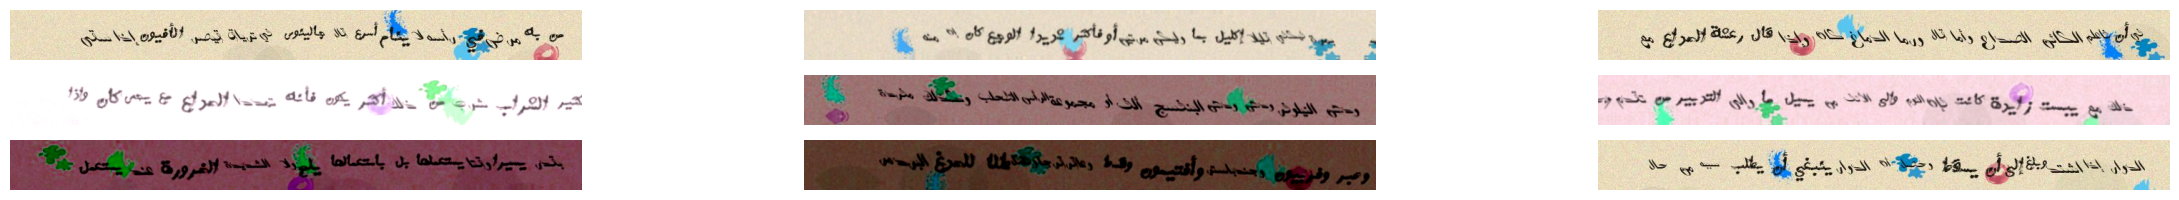

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf

dpi = 100  # typical DPI for matplotlib

# Take one batch from the dataset
for (image_batch, txt_batch), labels_batch in train_ds.take(1):

    # Denormalize the batch (multiply all images by 255)
    image_batch_denorm = image_batch * 255

    # Convert first image to get width and height
    image = image_batch_denorm[0]
    height, width, _ = image.shape

    # Set up figure
    fig, axs = plt.subplots(3, 3, figsize=(width * 3 / dpi, height * 3 / dpi), dpi=dpi)
    axs = axs.flatten()

    for i in range(min(9, image_batch_denorm.shape[0])):
        axs[i].imshow(image_batch_denorm[i].numpy().astype("uint8"))
        axs[i].axis("off")

    # Hide unused subplots
    for j in range(i + 1, 9):
        axs[j].axis("off")

    plt.tight_layout()
    plt.show()

The dataset now returns `(input, label)` pairs suitable for training with keras. The `inputs` are `(images, input_tokens)` pairs. The `images` have been processed with the feature-extractor model. For each location in the `input_tokens` the model looks at the text so far and tries to predict the next which is lined up at the same location in the `labels`.

In [ ]:
for inputs, ex_labels in train_ds.take(1):
    ex_img, ex_in_tok = inputs

print(ex_img.shape)
print(ex_in_tok.shape)
print(ex_labels.shape)

(32, 70, 800, 3)
(32, 18)
(32, 18)


The input tokens and the labels are the same, just shifted by 1 step:

In [ ]:
print(ex_in_tok[0].numpy())
print(ex_labels[0].numpy())

[   2   87  255 1951  238 5728 2373   15  174   20  800   42    0    0
    0    0    0    0]
[  87  255 1951  238 5728 2373   15  174   20  800   42    3    0    0
    0    0    0    0]


## A Transformer decoder model

This model assumes that the pretrained image encoder is sufficient, and just focuses on building the text decoder. This tutorial uses a 2-layer Transformer-decoder.

The implementations are almost identical to those in the [Transformers tutorial](https://www.tensorflow.org/text/tutorials/transformer). Refer back to it for more details.

<table>
<tr>
  <th>The Transformer encoder and decoder.</th>
</tr>
<tr>
  <td>
   <img width=400 src="https://www.tensorflow.org/images/tutorials/transformer/Transformer-1layer-words.png"/>
  </td>
</tr>
</table>

The model will be implemented in three main parts:

1. Input - The token embedding and positional encoding (`SeqEmbedding`).
1. Decoder - A stack of transformer decoder layers (`DecoderLayer`) where each contains:
   1. A causal self attention later (`CausalSelfAttention`), where each output location can attend to the output so far.
   1. A cross attention layer (`CrossAttention`) where each output location can attend to the input image.
   1. A feed forward network (`FeedForward`) layer which further processes each output location independently.
1. Output - A multiclass-classification over the output vocabulary.


### Input

The input text has already been split up into tokens and converted to sequences of IDs.

Remember that unlike a CNN or RNN the Transformer's attention layers are invariant to the order of the sequence. Without some positional input, it just sees an unordered set not a sequence. So in addition to a simple vector embedding for each token ID, the embedding layer will also include an embedding for each position in the sequence.

The `SeqEmbedding` layer defined below:

- It looks up the embedding vector for each token.
- It looks up an embedding vector for each sequence location.
- It adds the two together.
- It uses `mask_zero=True` to initialize the keras-masks for the model.

Note: This implementation learns the position embeddings instead of using fixed embeddings like in the [Transformer tutorial](https://www.tensorflow.org/text/tutorials/transformer). Learning the embeddings is slightly less code, but doesn't generalize to longer sequences.

In [ ]:
class SeqEmbedding(tf.keras.layers.Layer):
    def __init__(self, vocab_size, max_length, depth):
        super().__init__()
        self.pos_embedding = tf.keras.layers.Embedding(
            input_dim=max_length, output_dim=depth
        )

        self.token_embedding = tf.keras.layers.Embedding(
            input_dim=vocab_size, output_dim=depth, mask_zero=True
        )

        self.add = tf.keras.layers.Add()

    def call(self, seq):
        seq = self.token_embedding(seq)  # (batch, seq, depth)

        x = tf.range(tf.shape(seq)[1])  # (seq)
        x = x[tf.newaxis, :]  # (1, seq)
        x = self.pos_embedding(x)  # (1, seq, depth)

        return self.add([seq, x])

### Decoder

The decoder is a standard Transformer-decoder, it contains a stack of `DecoderLayers` where each contains three sublayers: a `CausalSelfAttention`, a `CrossAttention`, and a`FeedForward`. The implementations are almost identical to the [Transformer tutorial](https://www.tensorflow.org/text/tutorials/transformer), refer to it for more details.

The `CausalSelfAttention` layer is below:

In [ ]:
class CausalSelfAttention(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__()
        self.mha = tf.keras.layers.MultiHeadAttention(**kwargs)
        self.add = tf.keras.layers.Add()
        self.layernorm = tf.keras.layers.LayerNormalization()

    def call(self, x, attention_mask=None, training=False):
        attn = self.mha(
            query=x,
            value=x,
            use_causal_mask=True,
            attention_mask=attention_mask,
            training=training,
        )
        x = self.add([x, attn])
        return self.layernorm(x, training=training)

    def get_config(self):
        config = super().get_config()
        config.update(self.mha.get_config())
        return config

The `CrossAttention` layer is below. Note the use of `return_attention_scores`.

In [ ]:
class CrossAttention(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__()
        self.mha = tf.keras.layers.MultiHeadAttention(**kwargs)
        self.add = tf.keras.layers.Add()
        self.layernorm = tf.keras.layers.LayerNormalization()

    def call(self, x, y, **kwargs):

        attn_output, attention_scores = self.mha(
            query=x, value=y, return_attention_scores=True, **kwargs
        )

        self.last_attention_scores = attention_scores
        x = self.add([x, attn_output])
        return self.layernorm(x)

The `FeedForward` layer is below. Remember that a `layers.Dense` layer is applied to the last axis of the input. The input will have a shape of `(batch, sequence, channels)`, so it automatically applies pointwise across the `batch` and `sequence` axes.  

In [ ]:
class FeedForward(tf.keras.layers.Layer):
    def __init__(self, units, dropout_rate=0.5):
        super().__init__()
        self.seq = tf.keras.Sequential(
            [
                tf.keras.layers.Dense(units=2 * units, activation="relu"),
                tf.keras.layers.Dense(units=units),
                tf.keras.layers.Dropout(rate=dropout_rate),
            ]
        )

        self.layernorm = tf.keras.layers.LayerNormalization()

    def call(self, x, training=False):
        x = x + self.seq(x, training=training)
        return self.layernorm(x)

Next arrange these three layers into a larger `DecoderLayer`. Each decoder layer applies the three smaller layers in sequence. After each sublayer the shape of `out_seq` is `(batch, sequence, channels)`. The decoder layer also returns the `attention_scores` for later visualizations.

In [ ]:
class DecoderLayer(tf.keras.layers.Layer):
    def __init__(self, units, num_heads=1, dropout_rate=0.1):
        super().__init__()

        self.self_attention = CausalSelfAttention(
            num_heads=num_heads, key_dim=units, dropout=dropout_rate
        )
        self.cross_attention = CrossAttention(
            num_heads=num_heads, key_dim=units, dropout=dropout_rate
        )
        self.ff = FeedForward(units=units, dropout_rate=dropout_rate)

    def call(self, inputs, training=False):
        in_seq, out_seq = inputs

        # Text input
        out_seq = self.self_attention(out_seq, training=training)

        out_seq = self.cross_attention(out_seq, in_seq, training=training)

        self.last_attention_scores = self.cross_attention.last_attention_scores

        out_seq = self.ff(out_seq, training=training)

        return out_seq

### Output

At minimum the output layer needs a `layers.Dense` layer to generate logit-predictions for each token at each location.

But there are a few other features you can add to make this work a little better:

1. **Handle bad tokens**: The model will be generating text. It should
   never generate a pad, unknown, or start token (`''`, `'[UNK]'`,
   `'[START]'`). So set the bias for these to a large negative value.

   > Note: You'll need to ignore these tokens in the loss function as well.

2. **Smart initialization**: The default initialization of a dense layer will
  give a model that initially predicts each token with almost uniform
  likelihood. The actual token distribution is far from uniform. The
  optimal value for the initial bias of the output layer is the log of the
  probability of each token. So include an `adapt` method to count the tokens
  and set the optimal initial bias. This reduces the initial loss from the
  entropy of the uniform distribution (`log(vocabulary_size)`) to the marginal
  entropy of the distribution (`-p*log(p)`).


In [ ]:
# @title
class TokenOutput(tf.keras.layers.Layer):
    def __init__(self, tokenizer, banned_tokens=("", "[UNK]", "[START]"), **kwargs):
        super().__init__()

        self.dense = tf.keras.layers.Dense(units=tokenizer.vocabulary_size(), **kwargs)
        self.tokenizer = tokenizer
        self.banned_tokens = banned_tokens

        self.bias = None

    def adapt(self, ds):
        counts = collections.Counter()
        vocab_dict = {
            name: id for id, name in enumerate(self.tokenizer.get_vocabulary())
        }

        for tokens in tqdm.tqdm(ds):
            counts.update(tokens.numpy().flatten())

        counts_arr = np.zeros(shape=(self.tokenizer.vocabulary_size(),))
        counts_arr[np.array(list(counts.keys()), dtype=np.int32)] = list(
            counts.values()
        )

        counts_arr = counts_arr[:]
        for token in self.banned_tokens:
            counts_arr[vocab_dict[token]] = 0

        total = counts_arr.sum()
        p = counts_arr / total
        p[counts_arr == 0] = 1.0
        log_p = np.log(p)  # log(1) == 0

        entropy = -(log_p * p).sum()

        print()
        print(f"Uniform entropy: {np.log(self.tokenizer.vocabulary_size()):0.2f}")
        print(f"Marginal entropy: {entropy:0.2f}")

        self.bias = log_p
        self.bias[counts_arr == 0] = -1e9

    def call(self, x):
        x = self.dense(x)
        # TODO(b/250038731): Fix this.
        # An Add layer doesn't work because of the different shapes.
        # This clears the mask, that's okay because it prevents keras from rescaling
        # the losses.
        return x + self.bias

The smart initialization will significantly reduce the initial loss:

In [ ]:
output_layer = TokenOutput(tokenizer, banned_tokens=("", "[UNK]", "[START]"))
# This might run a little faster if the dataset didn't also have to load the image data.
output_layer.adapt(train_ds.map(lambda inputs, labels: labels))

699it [03:35,  4.08it/s]

### Build the model

To build the model, you need to combine several parts:

1. The image `feature_extractor` and the text `tokenizer` and.
1. The `seq_embedding` layer, to convert batches of token-IDs to
   vectors `(batch, sequence, channels)`.
3. The stack of `DecoderLayers` layers that will process the text and image data.
4. The `output_layer` which returns a pointwise prediction of what the next word should be.

In [ ]:
class Captioner(tf.keras.Model):
    @classmethod
    def add_method(cls, fun):
        setattr(cls, fun.__name__, fun)
        return fun

    def __init__(
        self,
        tokenizer,
        feature_extractor,
        output_layer,
        num_layers=1,
        units=256,
        max_length=50,
        num_heads=1,
        dropout_rate=0.1,
    ):
        super().__init__()
        self.feature_extractor = feature_extractor
        self.tokenizer = tokenizer
        self.word_to_index = tf.keras.layers.StringLookup(
            mask_token="", vocabulary=tokenizer.get_vocabulary()
        )
        self.index_to_word = tf.keras.layers.StringLookup(
            mask_token="", vocabulary=tokenizer.get_vocabulary(), invert=True
        )

        self.seq_embedding = SeqEmbedding(
            vocab_size=tokenizer.vocabulary_size(), depth=units, max_length=max_length
        )

        self.decoder_layers = [
            DecoderLayer(units, num_heads=num_heads, dropout_rate=dropout_rate)
            for n in range(num_layers)
        ]

        self.output_layer = output_layer

    def build(self, input_shape):
        # No actual building is needed since everything is dynamic
        pass

When you call the model, for training, it receives an `image, txt` pair. To make this function more usable, be flexible about the input:

* If the image has 3 channels run it through the feature_extractor. Otherwise assume that it has been already. Similarly
* If the text has dtype `tf.string` run it through the tokenizer.

After that running the model is only a few steps:

1. Flatten the extracted image features, so they can be input to the decoder layers.
2. Look up the token embeddings.
3. Run the stack of `DecoderLayer`s, on the image features and text embeddings.
4. Run the output layer to predict the next token at each position.


In [ ]:
  @Captioner.add_method
  def call(self, inputs):
    image, txt = inputs

    if image.shape[-1] == 3:
      # Apply the feature-extractor, if you get an RGB image.
      image = self.feature_extractor(image)

    # Flatten the feature map

    image = einops.rearrange(image, 'b h w c -> b (h w) c')


    if txt.dtype == tf.string:
      # Apply the tokenizer if you get string inputs.
      txt = tokenizer(txt)
    txt = self.seq_embedding(txt)
    # Look at the image
    for dec_layer in self.decoder_layers:
      txt = dec_layer(inputs=(image, txt))
    txt = self.output_layer(txt)

    return txt

In [ ]:
model = Captioner(
    tokenizer,
    feature_extractor=mobilenet,
    output_layer=output_layer,
    units=256,
    dropout_rate=0.3,
    num_layers=8,
    num_heads=2,
)

### Generate captions

Before getting into training, write a bit of code to generate captions. You'll use this to see how training is progressing.

Start by downloading a test image:

In [ ]:
image_url = (
    "https://drive.usercontent.google.com/download?id=1v_kXeI-ZNj6kjKYwYw9N9gg7f31JrE3U"
)
image_path = tf.keras.utils.get_file("surf.jpg", origin=image_url)
image = load_image(image_path)
# image= image/255
print(image.shape)

To caption an image with this model:

- Extract the `img_features`
- Initialize the list of output tokens with a `[START]` token.
- Pass `img_features` and `tokens` into the model.
  - It returns a list of logits.
  - Choose the next token based on those logits.  
  - Add it to the list of tokens, and continue the loop.
  - If it generates an `'[END]'` token, break out of the loop.

So add a "simple" method to do just that:

In [ ]:
@Captioner.add_method
def simple_gen(self, image, temperature=1):
    initial = self.word_to_index([["[START]"]])  # (batch, sequence)
    img_features = self.feature_extractor(image[tf.newaxis, ...])

    tokens = initial  # (batch, sequence)
    for n in range(50):
        preds = self((img_features, tokens)).numpy()  # (batch, sequence, vocab)
        preds = preds[:, -1, :]  # (batch, vocab)
        if temperature == 0:
            next = tf.argmax(preds, axis=-1)[:, tf.newaxis]  # (batch, 1)
        else:
            next = tf.random.categorical(
                preds / temperature, num_samples=1
            )  # (batch, 1)
        tokens = tf.concat([tokens, next], axis=1)  # (batch, sequence)

        if next[0] == self.word_to_index("[END]"):
            break
    words = index_to_word(tokens[0, 1:-1])
    result = tf.strings.reduce_join(words, axis=-1, separator=" ")
    return result.numpy().decode()

Here are some generated captions for that image, the model's untrained, so they don't make much sense yet:

In [ ]:
for t in (0.0, 0.5, 1.0):
    result = model.simple_gen(image, temperature=t)
    print("result: ", result)

The temperature parameter allows you to interpolate between 3 modes:

1. Greedy decoding (`temperature=0.0`) - Chooses the most likely next token at each step.
2. Random sampling according to the logits (`temperature=1.0`).
3. Uniform random sampling (`temperature >> 1.0`).

Since the model is untrained, and it used the frequency-based initialization, the "greedy" output (first) usually only contains the most common tokens: `['a', '.', '[END]']`.

## Train

To train the model you'll need several additional components:

- The Loss and metrics
- The Optimizer
- Optional Callbacks

### Losses and metrics

Here's an implementation of a masked loss and accuracy:

When calculating the mask for the loss, note the `loss < 1e8`. This term discards the artificial, impossibly high losses for the `banned_tokens`.

In [ ]:
def masked_loss(labels, preds):
    labels = tf.cast(labels, tf.int64)
    loss = tf.nn.sparse_softmax_cross_entropy_with_logits(labels, preds)

    mask = (labels != 0) & (loss < 1e8)
    mask = tf.cast(mask, loss.dtype)

    loss = loss * mask
    loss = tf.reduce_sum(loss) / tf.reduce_sum(mask)
    return loss


def masked_acc(labels, preds):

    mask = tf.cast(labels != 0, tf.float32)
    preds = tf.argmax(preds, axis=-1)
    labels = tf.cast(labels, tf.int64)
    match = tf.cast(preds == labels, mask.dtype)
    acc = tf.reduce_sum(match * mask) / tf.reduce_sum(mask)
    return acc

### Callbacks

For feedback during training setup a `keras.callbacks.Callback` to generate some captions for the surfer image at the end of each epoch.

In [ ]:
class GenerateText(tf.keras.callbacks.Callback):
    def __init__(self):
        image_url = "https://drive.usercontent.google.com/download?id=1v_kXeI-ZNj6kjKYwYw9N9gg7f31JrE3U"
        image_path = tf.keras.utils.get_file("surf.jpg", origin=image_url)
        self.image = load_image(image_path) / 255

    def on_epoch_end(self, epochs=None, logs=None):
        print()
        print()
        for t in (0.0, 0.5, 1.0):
            result = self.model.simple_gen(self.image, temperature=t)
            print(result)
        print()

It generates three output strings, like the earlier example, like before the first is "greedy", choosing the argmax of the logits at each step.

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint

# convert the extension of the saved modle to keras

checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath="drive/MyDrive/8D_model_weights_v4_temp.weights.h5",
    save_weights_only=True,
    save_best_only=True,
    monitor="val_loss",
    mode="min",
)
# lr_scheduler = ReduceLROnPlateau(
#     monitor='val_loss',
#     factor=0.2,
#     patience=3,
#     min_lr=1e-12,
#     verbose=1
# )

Also use `callbacks.EarlyStopping` to terminate training when the model starts to overfit.

In [ ]:
callbacks = [
    GenerateText(),
    checkpoint_cb,
    # lr_scheduler
    # tf.keras.callbacks.EarlyStopping(
    #     patience=5, restore_best_weights=True)
]

### Train

In [ ]:
model.load_weights("drive/MyDrive/8D_model_weights_v4_temp.weights.h5")

Configure and execute the training.

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=masked_loss,
    metrics=[masked_acc],
)

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.repeat().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.repeat().prefetch(buffer_size=AUTOTUNE)
steps_per_epoch = int(8000 / batch_size)
validation_steps = int(2000 / batch_size)

In [ ]:
model.layers

For more frequent reporting, use the `Dataset.repeat()` method, and set the `steps_per_epoch` and `validation_steps` arguments to `Model.fit`.

With this setup on `Flickr8k` a full pass over the dataset is 900+ batches, but below the reporting-epochs are 100 steps.

In [ ]:
# effnet = model.get_layer("functional_8")
# effnet_model = Model(inputs=effnet.input, outputs=effnet.output)
# effnet_model.save("drive/MyDrive/text_feature_extractor_v4.keras")

In [ ]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=30,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks,
)

Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 692ms/step - loss: 0.1533 - masked_acc: 0.9778

من عبد الرحمن في هذه ﻣﻦ ﻛﺎﻥ في هذه
من عبد الرحمن في هذه ﻳﺮﺗﻔﻊ عشرة التي ﺍﺑﻦ
ﺩﻡ ﺇﺧﺮﺍﺝ في بيدلو ضوء عندهم وديعن ﺇﺫﺍ وجوارحاً ﻓﺄﺻﺎﺑﻬﻤﺎ تغيره

250/250 ━━━━━━━━━━━━━━━━━━━━ 291s 842ms/step - loss: 0.1533 - masked_acc: 0.9778 - val_loss: 0.3068 - val_masked_acc: 0.9445
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 706ms/step - loss: 0.1651 - masked_acc: 0.9751

على ان كان في هذه هذه ذلك في كل كل
وان كان ما كان في ذلك ما خير لا ما كان
عليه انه ما الحاكم بحكى فلا فرحاً وانى ما والمياه ﺍﻟﻠﻮﺯﻭ

250/250 ━━━━━━━━━━━━━━━━━━━━ 216s 866ms/step - loss: 0.1654 - masked_acc: 0.9750 - val_loss: 0.2844 - val_masked_acc: 0.9525
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 727ms/step - loss: 4.5325 - masked_acc: 0.3583

من ذلك من كل من جهة او من جهة الا ما كان لا
من رطب فى اكل من جهة ابن وعن حديث متى فى ذلك
من ﺃﺩﻭﻳﺔ مع شمشوم محله ﻭﺍﻷﺷﻴﺎ تلك الشاعر مدرسَة النفوس سائر

250/250 ━━━━━━━━━━━━━━━━━━━━ 244s 977ms/step - loss: 4.5

Plot the loss and accuracy over the training run:

In [ ]:
# plt.plot(history.history['loss'], label='loss')
# plt.plot(history.history['val_loss'], label='val_loss')
# plt.ylim([0, max(plt.ylim())])
# plt.xlabel('Epoch #')
# plt.ylabel('CE/token')
# plt.legend()

In [ ]:
# plt.plot(history.history['masked_acc'], label='accuracy')
# plt.plot(history.history['val_masked_acc'], label='val_accuracy')
# plt.ylim([0, max(plt.ylim())])
# plt.xlabel('Epoch #')
# plt.ylabel('CE/token')
# plt.legend()

In [ ]:
l = list(test_ds.take(10))
img, text = l[3]
t = text[0].numpy()
w = tf.convert_to_tensor(index_to_word(t))
s = tf.strings.reduce_join(w, separator=" ", axis=-1)
print(s.numpy().decode())

image_batch = img[0].numpy()
image_batch[0] = image_batch[0] * 255
plt.imshow(image_batch[0].astype("uint8"))
plt.axis("off")
plt.show()

## Attention plots

In [ ]:
image = image_batch[0] / 255
result = model.simple_gen(image, temperature=0.0)
result

plt.imshow(image/255)
plt.axis("off")
plt.show()

Now, using the trained model,  run that `simple_gen` method on the image:

Split the output back into tokens:

In [ ]:
str_tokens = result.split()
str_tokens.append("[END]")

The `DecoderLayers` each cache the attention scores for their `CrossAttention` layer. The shape of each attention map is `(batch=1, heads, sequence, image)`:

In [ ]:
attn_maps = [layer.last_attention_scores for layer in model.decoder_layers]
[map.shape for map in attn_maps]

So stack the maps along the `batch` axis, then average over the `(batch, heads)` axes, while splitting the `image` axis back into `height, width`:


In [ ]:
test_img_batch = image[tf.newaxis, :]
img_features_shape = model.feature_extractor(test_img_batch).shape

# Extract the height and width of the feature map
feature_height = img_features_shape[1]
feature_width = img_features_shape[2]

# Concatenate the attention maps as before
attention_maps = tf.concat(attn_maps, axis=0)

# Use the dynamically determined feature_height and feature_width in the einops.reduce pattern
attention_maps = einops.reduce(
    attention_maps,
    "batch heads sequence (height width) -> sequence height width",
    height=feature_height,
    width=feature_width,
    reduction="mean",
)

Now you have a single attention map, for each sequence prediction. The values in each map should sum to `1.`

In [ ]:
einops.reduce(attention_maps, "sequence height width -> sequence", reduction="sum")

So here is where the model was focusing attention while generating each token of the output:

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def plot_attention_maps(image, str_tokens, attention_map):
    num_tokens = len(str_tokens)

    # Adjust figure size to make everything bigger
    fig = plt.figure(
        figsize=(num_tokens * 2.5, 6)
    )  # width increases with number of tokens

    # Determine grid size
    num_cols = min(num_tokens, 8)  # show max 8 tokens per row
    num_rows = int(np.ceil(num_tokens / num_cols))

    for i in range(num_tokens):
        ax = fig.add_subplot(num_rows, num_cols, i + 1)
        ax.set_title(str_tokens[i], fontsize=12)
        img = ax.imshow(image)
        ax.imshow(
            attention_map[i],
            cmap="gray",
            alpha=0.6,
            extent=img.get_extent(),
            clim=[0.0, np.max(attention_map[i])],
        )
        ax.axis("off")  # hide axes for clarity

    plt.tight_layout()
    plt.show()

In [ ]:
plot_attention_maps(image, str_tokens, attention_maps)

Now put that together into a more usable function:

In [ ]:
@Captioner.add_method
def run_and_show_attention(self, image, temperature=0.0):
    result_txt = self.simple_gen(image, temperature)
    str_tokens = result_txt.split()
    str_tokens.append("[END]")

    attention_maps = [layer.last_attention_scores for layer in self.decoder_layers]
    attention_maps = tf.concat(attention_maps, axis=0)

    # Get the image features shape to determine the correct height and width
    img_features_shape = self.feature_extractor(image[tf.newaxis, ...]).shape

    # The spatial dimensions are the second and third dimensions (index 1 and 2)
    feature_map_height = img_features_shape[1]
    feature_map_width = img_features_shape[2]

    attention_maps = einops.reduce(
        attention_maps,
        "batch heads sequence (height width) -> sequence height width",
        height=feature_map_height,
        width=feature_map_width,
        reduction="mean",
    )

    plot_attention_maps(image, str_tokens, attention_maps)
    t = plt.suptitle(result_txt)
    t.set_y(1.05)

In [ ]:
run_and_show_attention(model, image)

In [ ]:
!unrar x -y "img.rar" "test/"

## Try it on your own images

For fun, below you're provided a method you can use to caption your own images with the model you've just trained. Keep in mind, it was trained on a relatively small amount of data, and your images may be different from the training data (so be prepared for strange results!)


In [ ]:
# image= load_image('test/images/page_6.jpg')

# image= image/255
# r=model.simple_gen(image)
# r

# run_and_show_attention(model, image)